### Applying Isolation Forest algorithm to flag unstable satellites
- We will now train Isolation forest on each satellite cluster 

In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest


In [77]:
# 1. Read the unscaled clustered dataset
unscaled_df = pd.read_csv('../data/05_labeled/satellites_unscaled_labeled.csv')
# 2. Read the scaled clustered dataset
scaled_df = pd.read_csv('../data/05_labeled/satellites_scaled_labeled.csv')

In [78]:
unscaled_df.head()

,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,...,SAT_TYPE_R,SAT_TYPE_S,SAT_TYPE_T,SAT_TYPE_U,SAT_TYPE_V,SAT_TYPE_W,SAT_TYPE_X,SAT_TYPE_Y,SAT_TYPE_Z,CLUSTER
0,13.763395,0.002678,90.2215,67.1407,174.9399,258.9789,4390,0.000815,8.060000e-06,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,13.528812,0.002053,90.2363,71.0754,88.8358,28.0961,82921,0.000042,3.700000e-07,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,13.335805,0.007145,89.9891,212.6810,90.4072,62.5157,93338,0.000091,5.500000e-07,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,13.362355,0.006838,89.9087,124.3593,308.8371,226.1500,93599,0.000265,1.470000e-06,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,14.738530,0.000482,69.9174,167.1531,291.9090,68.1543,3672,0.001379,8.985000e-05,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [79]:
scaled_df.head()

,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,...,SAT_TYPE_R,SAT_TYPE_S,SAT_TYPE_T,SAT_TYPE_U,SAT_TYPE_V,SAT_TYPE_W,SAT_TYPE_X,SAT_TYPE_Y,SAT_TYPE_Z,CLUSTER
0,-2.023660,0.721456,1.359665,-0.980813,0.133186,0.641852,-0.682557,0.142851,0.010382,-0.027989,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,-2.402606,0.511860,1.360380,-0.944014,-0.785752,-1.815440,5.221362,0.003565,0.007018,-0.027989,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,-2.714390,2.220199,1.348440,0.380358,-0.768982,-1.449111,6.004506,0.012454,0.007097,-0.027989,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,-2.671502,2.117011,1.344556,-0.445674,1.562190,0.292453,6.024128,0.043789,0.007499,-0.027989,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,-0.448421,-0.015017,0.378947,-0.045443,1.381527,-1.389099,-0.736536,0.244492,0.046157,-0.027989,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


---
## 🛰️ Cluster-Wise Isolation Forest: Abstract Workflow

Below is a high-level, implementation-agnostic explanation of how to run
**Isolation Forest separately on each cluster**, with parameters that adapt
to each cluster’s size and spread.

---

### 1. **Prepare Cluster Subsets**
After clustering (e.g., via K-Means), split the dataset into groups:

- Each group represents one cluster.
- Each cluster is treated as its own “local data pocket.”
- Compute basic stats per cluster:
  - `nᵢ` → number of points  
  - `σᵢ` → average standard deviation (or IQR) -> take average sd of every feature

These two values guide all later parameter choices.

---

### 2. **Set Cluster-Specific Parameters**
For every cluster **Cᵢ**:

**a. n_estimators (tree count)**  
Adjust based on cluster size:
- Small clusters → fewer trees  
- Medium → moderate  
- Large → slightly more

**b. max_samples**  
Use the smaller of:
- the cluster size,  
- a fixed cap (traditional ≈ 256)

This keeps trees consistent but efficient.

**c. contamination**  
Link sensitivity to cluster spread:
- Tight/compact clusters → very low contamination  
- Medium spread → moderate  
- High-spread/noisy clusters → slightly higher

This makes each model respect its own local variance.

**d. max_features**  
Use all features inside each cluster.  
Local models benefit from full context.

**e. bootstrap**  
Only enable if the cluster is very large.

---

### 3. **Train a Local Isolation Forest Inside Each Cluster**
- Fit the detector using that cluster’s own data only.
- The model isolates anomalies relative to the internal geometry of the cluster.
- No global interference from other clusters.

This produces cluster-wise anomaly scores.

---

### 4. **Normalize Scores Inside Each Cluster**
Each cluster’s score distribution is different.

Normalize scores cluster-wise, for example:
- min–max scaling  
- or z-score

This ensures that anomaly scores across clusters become comparable.

---

### 5. **Merge All Results**
Bring everything back together:

- Reattach the cluster label  
- Append the normalized anomaly score  
- Combine all cluster outputs into one final dataframe

The final result gives:
- local anomaly detection quality  
- global comparability  
- very stable and interpretable behavior

---

### 🧭 Outcome
You get a lightweight, cluster-sensible anomaly system where:
- each cluster has a detector tuned to its density and size  
- anomaly detection is cleaner and more precise  
- merged scores reflect global anomaly significance without distortion

This structure is simple, scalable, and strong for datasets with natural subgroups
(e.g., orbital shells, behavioral clusters, sensor regimes, etc.).


---


- Check the raw size of the clusters

In [80]:
scaled_df['CLUSTER'].value_counts()

CLUSTER
2    4780
4    4349
1    2088
0    1441
3      38
Name: count, dtype: int64

---
### 1. Basic stats for each cluster -> Use scaled dataset for unbiased Standard Deviation
1. Satellite count
2. Average standard deviation across numerical features

In [81]:
# Find number of samples and mean SD 
def compute_base_stats(scaled_df):

    cluster_size_list = []
    sd_list = []
    value_counts = scaled_df['CLUSTER'].value_counts()
    
    # For each cluster: compute clust size and average SD
    for clust_id in sorted(value_counts.index):
        # --- clust size ---
        cluster_size_list.append(value_counts.loc[clust_id]) 
        
        # --- Average SD ---
        clust_rows = scaled_df[scaled_df['CLUSTER'] == clust_id] # filter out only this cluster satellites

        numeric_cols = clust_rows.select_dtypes(include = np.number).drop(columns=['CLUSTER']) # get numeric column names
        encoded_cols = [col for col in numeric_cols.columns if col.startswith('SAT_TYPE_')] # Filter out encoded features, as we dont need them for SD
        numeric_cols = numeric_cols.drop(columns = encoded_cols).columns
        
        total_sd = 0 # Find the SD for each feature, then add the SD for the current cluster's all features
        for feature in numeric_cols:
            sd = clust_rows[feature].std()
            total_sd += sd

        avg_sd = total_sd / len(numeric_cols) 
        sd_list.append(avg_sd)
        
    return cluster_size_list, sd_list
        

In [82]:
# Call the function
cluster_size, avg_sd = compute_base_stats(scaled_df)

In [83]:
cluster_size

[np.int64(1441), np.int64(2088), np.int64(4780), np.int64(38), np.int64(4349)]

In [84]:
avg_sd

[1.0367723258325598,
 0.6102511479492463,
 0.539331914174285,
 1.532623983475732,
 0.57523759030119]

----
### 2. Setting cluster specific parameters for Isolation Forest models
- For each cluster based on the size and Average SD, find:
1. **n_estimators**: Tree count
2. **max_samples**:  Num of samples to use in each isolation tree
3. **contamination**: Threshold by which anomaly will be selected
4. **max_features**: Use all features in every tree

---
## Mapping Cluster Stats → Isolation Forest Parameters (Intuition + Value Ranges)

### Inputs:
- **cluster_size** → number of satellites in this cluster  
- **cluster_sd** → how spread-out the cluster is (average SD of continuous features)

These two fully define how the Isolation Forest should be shaped.

---

## 1. contamination (comes from cluster_sd)

### Intuition:
“Tight cluster → fewer anomalies. Loose cluster → more anomalies.”

### Suggested values:
- **Low SD** (very tight) → `0.01` to `0.02`  
- **Medium SD** → `0.03` to `0.06`  
- **High SD** (very loose) → `0.08` to `0.12`  

---

## 2. n_estimators (comes from cluster_size)

### Intuition:
“Bigger clusters have more structure → need more trees.”

### Suggested values:
- **cluster_size < 100** → `50–100` trees  
- **100 ≤ size ≤ 1000** → `150–200` trees  
- **size > 3000** → `250–350` trees  

---

## 3. max_samples (also from cluster_size)

### Intuition:
“Small cluster → smaller subsamples. Big cluster → bigger subsamples.”

### Suggested values:
- **cluster_size < 100** → `40–80%` of the cluster  
- **100 ≤ size ≤ 1000** → `60–90%` of the cluster  
- **size > 3000** → fixed cap like `512` or `1024` samples  

---

## Summary Mapping
- **cluster_sd → contamination**  
- **cluster_size → n_estimators**  
- **cluster_size → max_samples**  

These three settings adjust the Isolation Forest to each cluster’s personality.


----
### Final value tables
#### 1. Contamination rule: 



Contamination is chosen by first selecting a system-wide range:
- Tight system  →  0.005 to 0.03  
- Normal system →  0.01  to 0.08  
- Loose system  →  0.02  to 0.12  

The chosen range is stretched across k positions (k = number of clusters) to form a smooth scale of contamination values from minimum to maximum.  
Cluster SD ordering determines each cluster’s position on this scale: tighter SD maps to lower contamination, looser SD maps to higher contamination, and identical SD values map to the same position.


---

#### 2. n_estimators rule: 
| Cluster Size Range | Meaning      | Recommended n_estimators |
| ------------------ | ------------ | ------------------------ |
| **< 100**          | Very Small   | **50–80**                |
| **100–1000**       | Small–Medium | **150–200**              |
| **1000–3000**      | Medium–Large | **200–250**              |
| **> 3000**         | Very Large   | **250–350**              |


---

#### 3. max_samples rule:
| Cluster Size Range | Meaning      | Recommended max_samples                      |
| ------------------ | ------------ | -------------------------------------------- |
| **< 100**          | Very Small   | **40–80%** of cluster size                   |
| **100–1000**       | Small–Medium | **60–90%** of cluster size                   |
| **1000–3000**      | Medium–Large | **approx 90–95%** of cluster size            |
| **> 3000**         | Very Large   | **Fixed cap: 512–1024** (regardless of size) |



In [85]:
def find_model_parameter(clust_sd, cluster_size):
    # df = scaled_df (just for this function)

    contamination_list, n_estimator_list, max_sample_list = [None]*len(clust_sd), [None]*len(clust_sd), [None]*len(clust_sd)

    # 1. Contamination (based on cluster SD)

    # Step 1: Compute SD spread
    spread = max(clust_sd) - min(clust_sd)
    
    # Step 2: Choose min/max contamination based on spread
    if spread <= 0.2:
        min_cont, max_cont = 0.005, 0.03
    elif spread <= 0.6:
        min_cont, max_cont = 0.01, 0.08
    else:
        min_cont, max_cont = 0.02, 0.12
    
    # Step 3: Generate contamination values (dynamic for any k)
    selected_sd_range = np.linspace(min_cont, max_cont, len(clust_sd))
    
    # Step 4: Group clusters by SD (equal SD → equal contamination)
    unique_sds = sorted(set(clust_sd))
    sd_to_rank = {sd: i for i, sd in enumerate(unique_sds)}
    
    # Step 5: Assign contamination using grouped ranks
    for i in range(len(clust_sd)):
        rank = sd_to_rank[clust_sd[i]] # which rank does the cluster with This SD has
        contamination_list[i] = selected_sd_range[rank]

    # ----------------------------------------------------------
    
    # 2. n_estimators &  max_samples (based on cluster size)

    for i in range(len(cluster_size)):
        if cluster_size[i] < 100: # Small sized cluster
            n_estimator_list[i] = 70
            max_sample_list[i] = int(cluster_size[i] * 0.5)
            
        elif cluster_size[i] <1000: # small to medium sized cluster
            n_estimator_list[i] = 150
            max_sample_list[i] = int(cluster_size[i] * 0.7)

        elif cluster_size[i] <3000: #  medium to large sized cluster
            n_estimator_list[i] = 200
            max_sample_list[i] = int(cluster_size[i] * 0.9)
            
        else:                     # Large sized cluster
            n_estimator_list[i] = 350
            max_sample_list[i] = 1000
     # ----------------------------------------------------------

    return contamination_list, n_estimator_list, max_sample_list
    
        

In [86]:
contamination_list, n_estimator_list, max_sample_list = find_model_parameter(avg_sd, cluster_size)

In [87]:
print(f"{'Cluster ID':<12} | {'Contamination':<15} | {'n_estimators':<12} | {'max_samples':<12}")
print("-" * 65)

for i in range(len(cluster_size)):
    print(f"{str(i):<12} | {contamination_list[i]:<15} | {n_estimator_list[i]:<12} | {max_sample_list[i]:<12}")


Cluster ID   | Contamination   | n_estimators | max_samples 
-----------------------------------------------------------------
0            | 0.095           | 200          | 1296        
1            | 0.06999999999999999 | 200          | 1879        
2            | 0.02            | 350          | 1000        
3            | 0.12            | 70           | 19          
4            | 0.045           | 350          | 1000        


In [88]:
cluster_size

[np.int64(1441), np.int64(2088), np.int64(4780), np.int64(38), np.int64(4349)]

In [89]:
print(f"{'Cluster ID':<12} | {'Contamination':<15} | {'n_estimators':<12} | {'max_samples':<12}")
print("-" * 65)

for i in range(len(cluster_size)):
    print(f"{str(i):<12} | {contamination_list[i]:<15} | {n_estimator_list[i]:<12} | {max_sample_list[i]:<12}")

Cluster ID   | Contamination   | n_estimators | max_samples 
-----------------------------------------------------------------
0            | 0.095           | 200          | 1296        
1            | 0.06999999999999999 | 200          | 1879        
2            | 0.02            | 350          | 1000        
3            | 0.12            | 70           | 19          
4            | 0.045           | 350          | 1000        


---

### Training Isolation Forest on each cluster

In [90]:
unscaled_df.head()

,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,...,SAT_TYPE_R,SAT_TYPE_S,SAT_TYPE_T,SAT_TYPE_U,SAT_TYPE_V,SAT_TYPE_W,SAT_TYPE_X,SAT_TYPE_Y,SAT_TYPE_Z,CLUSTER
0,13.763395,0.002678,90.2215,67.1407,174.9399,258.9789,4390,0.000815,8.060000e-06,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,13.528812,0.002053,90.2363,71.0754,88.8358,28.0961,82921,0.000042,3.700000e-07,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,13.335805,0.007145,89.9891,212.6810,90.4072,62.5157,93338,0.000091,5.500000e-07,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,13.362355,0.006838,89.9087,124.3593,308.8371,226.1500,93599,0.000265,1.470000e-06,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,14.738530,0.000482,69.9174,167.1531,291.9090,68.1543,3672,0.001379,8.985000e-05,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [91]:
# Function to train model
def train_iso_model(df, contamination, n_estimator, max_sample):

    iso_forest_models = {} # Store cluster ID: related iso model
    
    for cluster_id in sorted(list(set(df['CLUSTER']))):
        # Extract rows for this cluster ID
        cluster_rows = df[df['CLUSTER'] == cluster_id]

        iso_model = IsolationForest(n_estimators=n_estimator[cluster_id], 
                                   max_samples=max_sample[cluster_id],
                                   contamination=contamination[cluster_id],
                                   max_features=1.0, # Consider all features in a tree
                                   random_state=101)
        # Train the model
        iso_model.fit(cluster_rows.drop(columns=['CLUSTER']))
        iso_forest_models[cluster_id] = iso_model # Save the model to the dictionary

        print(f'Isolation forest trained for cluster {cluster_id}')

    return iso_forest_models

In [92]:
# Call the function to train (on unscaled dataset -> Isolation forest does not need scaling)
iso_forest_models = train_iso_model(unscaled_df, contamination_list, n_estimator_list, max_sample_list)

Isolation forest trained for cluster 0
Isolation forest trained for cluster 1
Isolation forest trained for cluster 2
Isolation forest trained for cluster 3
Isolation forest trained for cluster 4


In [93]:
iso_forest_models

{0: IsolationForest(contamination=np.float64(0.095), max_samples=1296,
                 n_estimators=200, random_state=101),
 1: IsolationForest(contamination=np.float64(0.06999999999999999), max_samples=1879,
                 n_estimators=200, random_state=101),
 2: IsolationForest(contamination=np.float64(0.02), max_samples=1000,
                 n_estimators=350, random_state=101),
 3: IsolationForest(contamination=np.float64(0.12), max_samples=19, n_estimators=70,
                 random_state=101),
 4: IsolationForest(contamination=np.float64(0.045), max_samples=1000,
                 n_estimators=350, random_state=101)}

In [94]:
# function to extract the anomaly information
def get_anomaly(iso_forest_models, df):

    # Prepare the anomaly realted features
    df['ANOMALY_LABEL'] = 0
    df['ANOMALY_SCORE'] = 0.0
    
    for cluster_id, model in iso_forest_models.items():
        # Select all rows belonging to this cluster
        mask = df['CLUSTER'] == cluster_id

        # Extract necessary features (features + rows belonging to the cluster)
        features = df.loc[mask].drop(columns=['CLUSTER', 'ANOMALY_LABEL', 'ANOMALY_SCORE'])

        # Predict using model trained on exact features
        labels = model.predict(features) 
        score = model.decision_function(features)

        # Store the results back to unscaled DF
        df.loc[mask, 'ANOMALY_LABEL'] = labels
        df.loc[mask, 'ANOMALY_SCORE'] = score

        print(f'Isolation forest predicted for cluster {cluster_id}')

    return df

In [95]:
anomaly_df = get_anomaly(iso_forest_models, unscaled_df)

Isolation forest predicted for cluster 0
Isolation forest predicted for cluster 1
Isolation forest predicted for cluster 2
Isolation forest predicted for cluster 3
Isolation forest predicted for cluster 4


In [96]:
anomaly_df.head()

,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,...,SAT_TYPE_T,SAT_TYPE_U,SAT_TYPE_V,SAT_TYPE_W,SAT_TYPE_X,SAT_TYPE_Y,SAT_TYPE_Z,CLUSTER,ANOMALY_LABEL,ANOMALY_SCORE
0,13.763395,0.002678,90.2215,67.1407,174.9399,258.9789,4390,0.000815,8.060000e-06,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,-1,-0.015037
1,13.528812,0.002053,90.2363,71.0754,88.8358,28.0961,82921,0.000042,3.700000e-07,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,-1,-0.017318
2,13.335805,0.007145,89.9891,212.6810,90.4072,62.5157,93338,0.000091,5.500000e-07,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,-1,-0.033164
3,13.362355,0.006838,89.9087,124.3593,308.8371,226.1500,93599,0.000265,1.470000e-06,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,-1,-0.063009
4,14.738530,0.000482,69.9174,167.1531,291.9090,68.1543,3672,0.001379,8.985000e-05,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,-1,-0.049294


In [97]:
anomaly_df['ANOMALY_LABEL'].value_counts()

ANOMALY_LABEL
 1    12115
-1      581
Name: count, dtype: int64

----


### Making a Streamlit ready dataset combining the result of clustering and anomaly detection, also useful for forecasting / risk analysis

In [98]:
# Read the orignal dataset to get the missing columns
original_df = pd.read_csv('../data/03_engineered/satellites_engineered.csv')

streamlit_ready_df = original_df.join(anomaly_df[['CLUSTER', 'ANOMALY_LABEL', 'ANOMALY_SCORE']])
    

In [99]:
streamlit_ready_df.head()

,OBJECT_NAME,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,NORAD_CAT_ID,REV_AT_EPOCH,...,SEMI_MAJOR_AXIS,ORBIT_HEIGHT,PERIGEE,APOGEE,ORBITAL_SPEED,AGE_SINCE_LAUNCH,SAT_TYPE,CLUSTER,ANOMALY_LABEL,ANOMALY_SCORE
0,CALSPHERE 1,2025-11-29 02:50:25.337184,13.763395,0.002678,90.2215,67.1407,174.9399,258.9789,900,4390,...,7354.966693,983.966693,957.272299,996.661088,7.361703,61.912,C,0,-1,-0.015037
1,CALSPHERE 2,2025-11-29 03:05:54.157920,13.528812,0.002053,90.2363,71.0754,88.8358,28.0961,902,82921,...,7439.743866,1068.743866,1046.470816,1077.016916,7.319639,61.912,E,0,-1,-0.017318
2,TEMPSAT 1,2025-11-29 03:03:30.714048,13.335805,0.007145,89.9891,212.6810,90.4072,62.5157,1512,93338,...,7511.354469,1140.354469,1079.682837,1187.026101,7.284664,60.912,E,0,-1,-0.033164
3,CALSPHERE 4A,2025-11-29 04:04:06.381120,13.362355,0.006838,89.9087,124.3593,308.8371,226.1500,1520,93599,...,7501.401745,1130.401745,1072.108660,1174.694830,7.289495,60.912,H,0,-1,-0.063009
4,OPS 5712 (P/L 160),2025-11-29 04:49:46.469856,14.738530,0.000482,69.9174,167.1531,291.9090,68.1543,2826,3672,...,7026.865500,655.865500,645.476443,652.254557,7.531610,58.912,A,0,-1,-0.049294


#### Save the dataset

In [100]:
streamlit_ready_df.to_csv('../data/06_streamlit_ready/anomaly_clustered.csv', index=False)

In [ ]:
# Validate the dataset row order
same = (original_df['OBJECT_NAME'].values == streamlit_ready_df['OBJECT_NAME'].values)

print("Rows matching:", same.sum(), "/", len(same))
print("All same?", same.all())

Rows matching: 12696 / 12696
All same? True


### Interpreting the results

#### 1. Sort satellites in that cluster by anomaly severity

In [102]:
def anomaly_severity(cluster_id, df):
    # Get anomalies from this cluster id sorted by anomaly score
    cluster_df = df[df['CLUSTER']==cluster_id].sort_values(by='ANOMALY_SCORE')

    # Get top 10 risky satellites
    top_10 = cluster_df.head(10)
    return top_10, cluster_df
    

In [103]:
print('top 10 anomalous satellites within each cluster')
for i in range(0, anomaly_df['CLUSTER'].nunique()):
    # Call the functon
    top_10, cluster_df = anomaly_severity(i, anomaly_df)

    print('-----------------------')
    print(f'Cluster ID {i}')
    print(top_10[['ANOMALY_SCORE']])
    print('\n')

top 10 anomalous satellites within each cluster
-----------------------
Cluster ID 0
       ANOMALY_SCORE
11885      -0.220628
178        -0.149921
11888      -0.122643
101        -0.121522
114        -0.103073
11886      -0.101595
11884      -0.100045
12091      -0.093188
12092      -0.092249
12093      -0.086627


-----------------------
Cluster ID 1
       ANOMALY_SCORE
460        -0.174436
4596       -0.157616
459        -0.152980
2445       -0.148989
12135      -0.119344
4544       -0.117135
279        -0.116030
12191      -0.078089
8329       -0.076279
8326       -0.075099


-----------------------
Cluster ID 2
       ANOMALY_SCORE
1112       -0.114096
6767       -0.110968
12150      -0.105557
5002       -0.103248
6766       -0.098977
12148      -0.098052
7229       -0.097303
6769       -0.096840
6768       -0.095294
12146      -0.095097


-----------------------
Cluster ID 3
       ANOMALY_SCORE
10911      -0.044708
230        -0.043852
10905      -0.031624
10909      -0.030739


---
#### 2. Anomaly distribution to see cluster behavior

##### A. Score distribution plot (1D histogram / KDE)

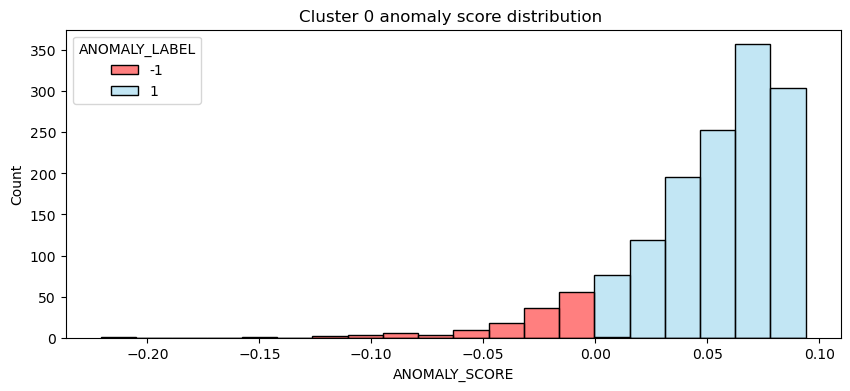

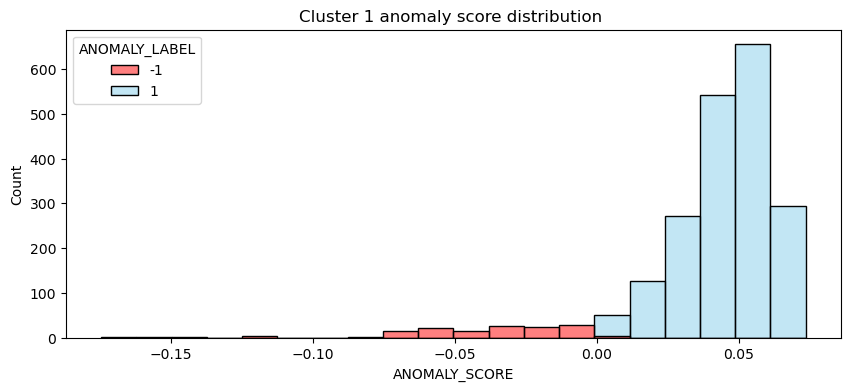

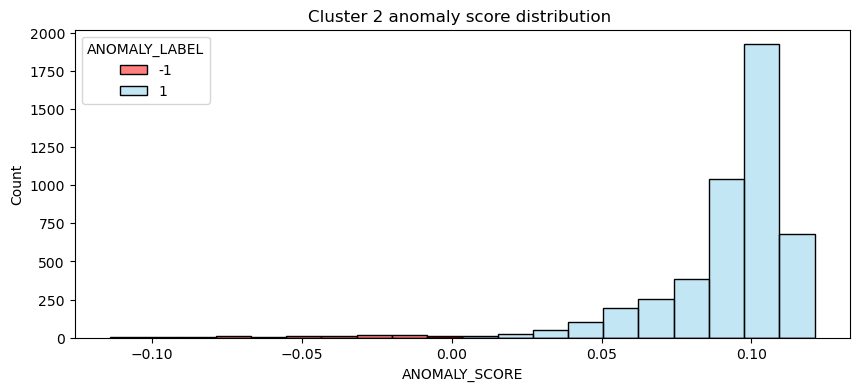

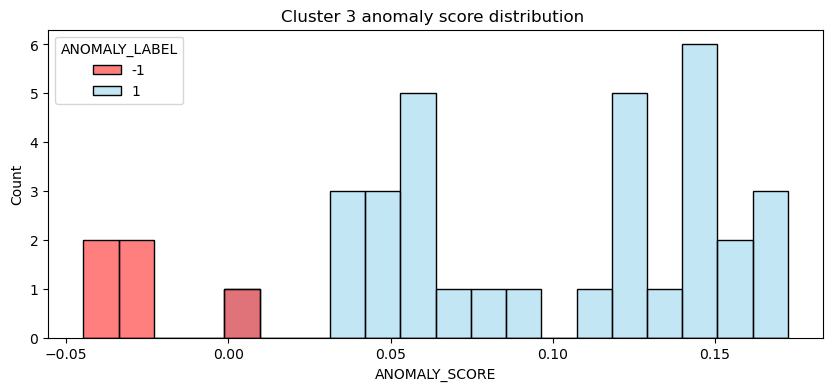

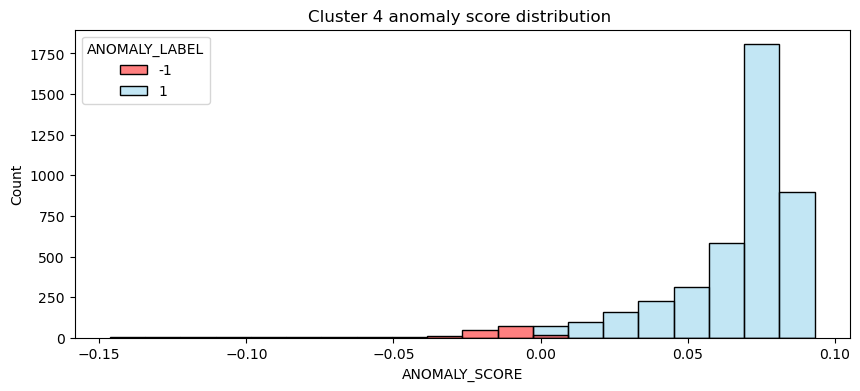

In [104]:
for cluster_id in range(0, anomaly_df['CLUSTER'].nunique()):
    # Call the function
    top_10, cluster_df = anomaly_severity(cluster_id, anomaly_df)
    
    plt.figure(figsize=(10, 4))
    plt.title(f'Cluster {cluster_id} anomaly score distribution ')
    sns.histplot(data =cluster_df,x = 'ANOMALY_SCORE', bins=20, hue='ANOMALY_LABEL', palette={1: "skyblue", -1: "red"})

#### B. 2D scatter: Altitude vs Mean Motion

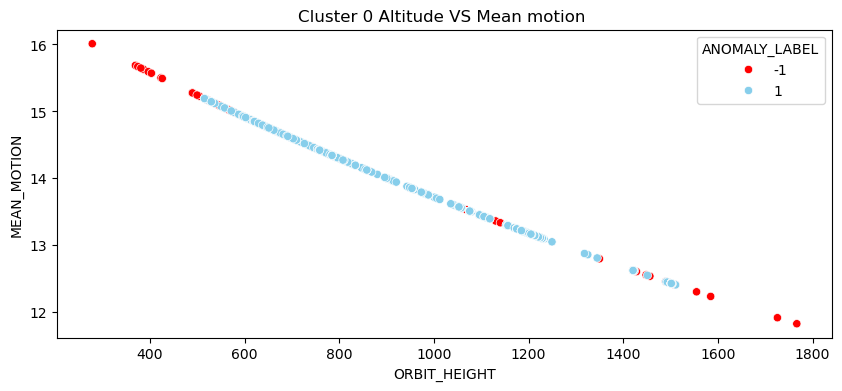

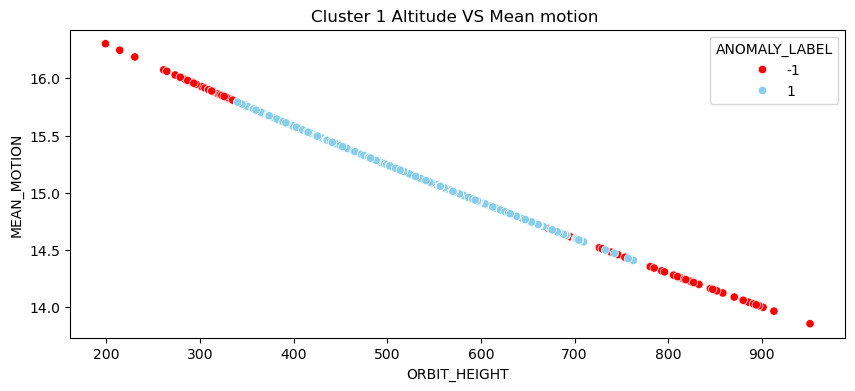

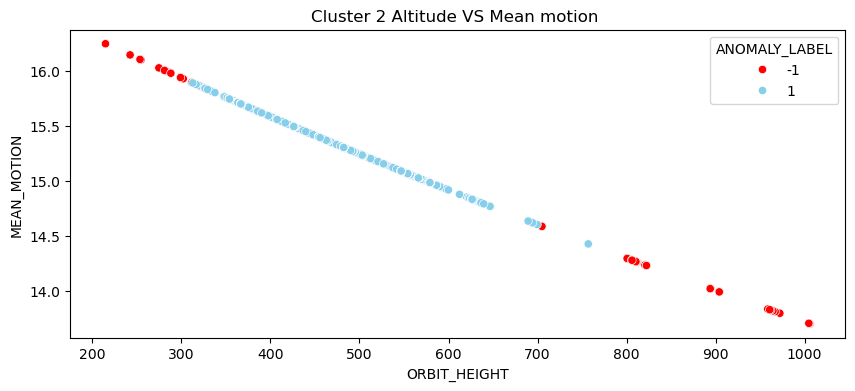

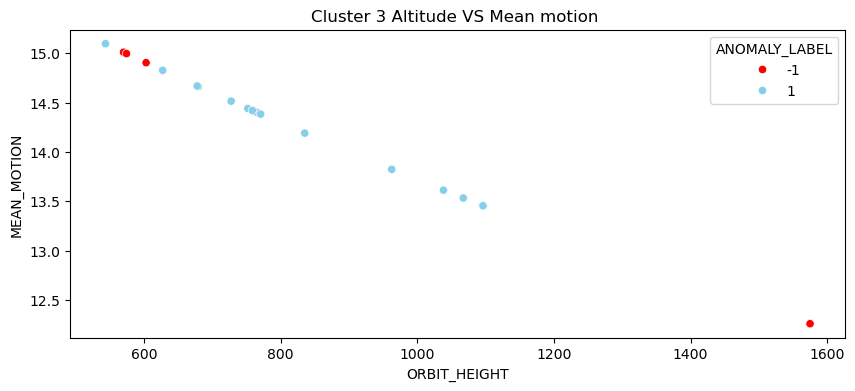

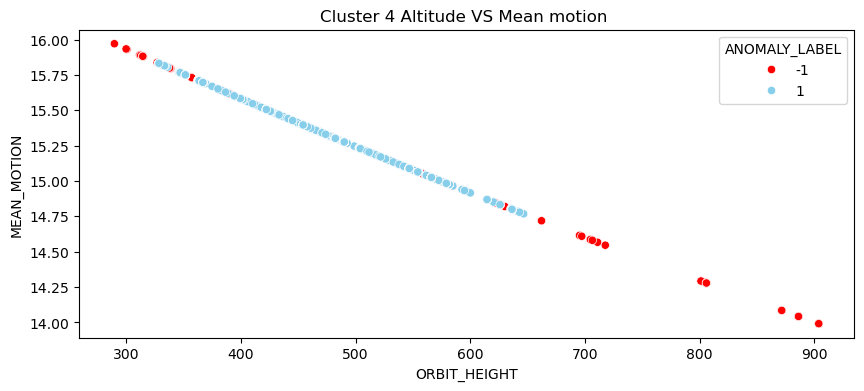

In [105]:
for cluster_id in range(0, anomaly_df['CLUSTER'].nunique()):
    # Call the function
    top_10, cluster_df = anomaly_severity(cluster_id, anomaly_df)
    
    plt.figure(figsize=(10, 4))
    plt.title(f'Cluster {cluster_id} Altitude VS Mean motion ')
    sns.scatterplot(data = cluster_df,x = 'ORBIT_HEIGHT', y = 'MEAN_MOTION', hue='ANOMALY_LABEL', palette={1: "skyblue", -1: "red"})

#### C. 2D scatter: BSTAR vs Altitude 

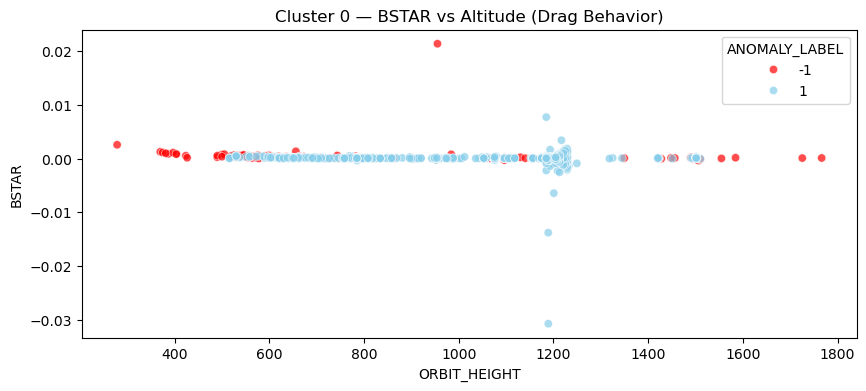

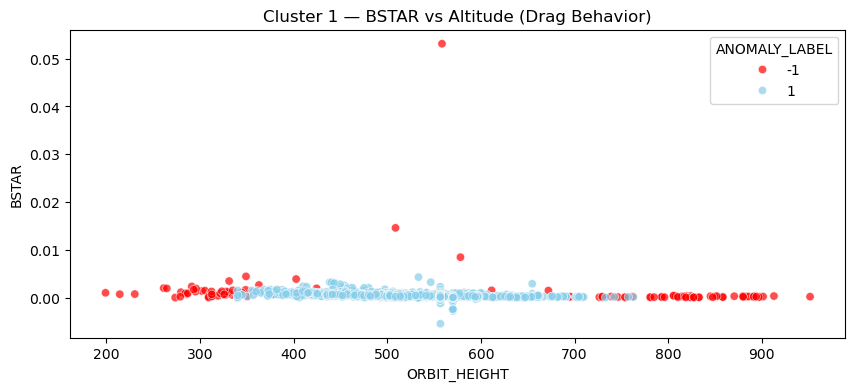

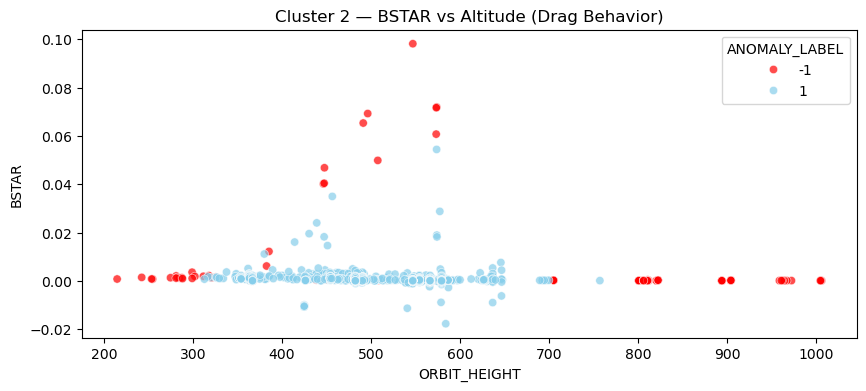

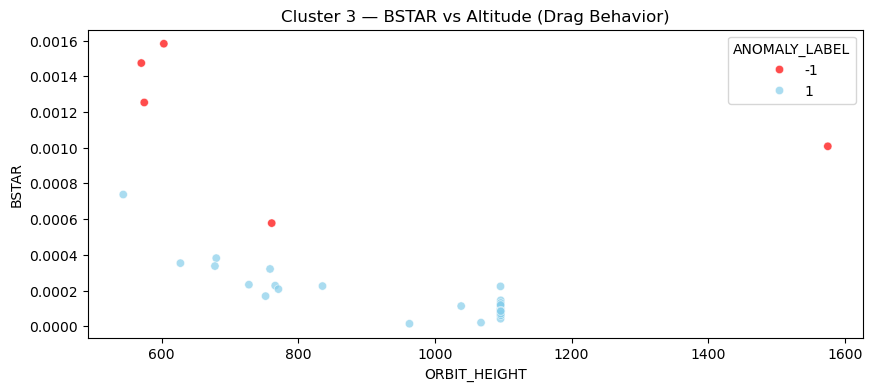

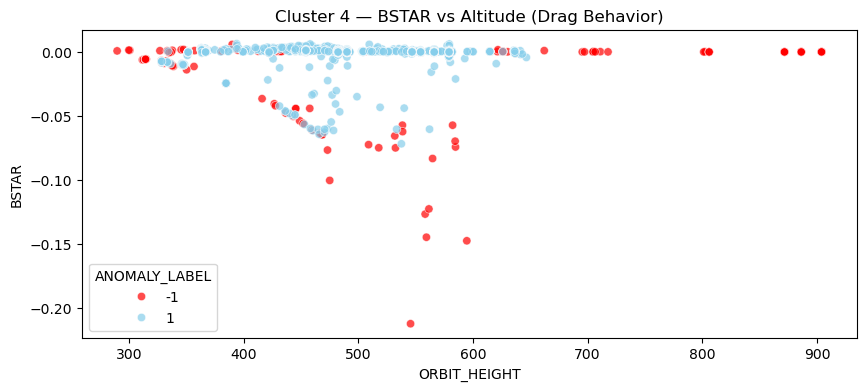

In [106]:
for cluster_id in range(0, anomaly_df['CLUSTER'].nunique()):
    # Call the function
    top_10, cluster_df = anomaly_severity(cluster_id, anomaly_df)
    
    plt.figure(figsize=(10, 4))
    plt.title(f'Cluster {cluster_id} — BSTAR vs Altitude (Drag Behavior)')
    sns.scatterplot(
        data=cluster_df,
        x='ORBIT_HEIGHT',
        y='BSTAR',
        hue='ANOMALY_LABEL',
        palette={1: "skyblue", -1: "red"},
        alpha=0.7
    )
  

----


### 3. Per-Anomaly Feature Deviation Detection

In [107]:
# All anomaly feature deviation (concat after each loop)
all_anomalies = []

for cluster_id in range(0, anomaly_df['CLUSTER'].nunique()):
    # Call the function
    top_10, cluster_df = anomaly_severity(cluster_id, anomaly_df)

    # Compute cluster means for selected features (important features)
    features = [
     "ORBIT_HEIGHT",
     "MEAN_MOTION",
     "ECCENTRICITY",
     "INCLINATION",
     "RA_OF_ASC_NODE",
     "ARG_OF_PERICENTER",
     "BSTAR",
     "PERIGEE",
     "APOGEE",
     "SEMI_MAJOR_AXIS",
     "ORBITAL_SPEED"
    ]
    cluster_mean = cluster_df[features].mean()

    # Get anomaly satellites
    anomalies = cluster_df[cluster_df['ANOMALY_LABEL']== -1].copy()

    # For each anomaly satellite:
    for i, row in anomalies.iterrows():
        # Store deviations for this satellite
        delta_dict = {}

        # Compare each feature value to the cluster mean
        for feature in features:
            delta = abs(row[feature] - cluster_mean[feature])

            delta_dict[feature] = delta

        # Identify heighest deviation feature(s)
        max_delta_value = max(delta_dict.values())
        max_delta_feature = max(delta_dict, key=delta_dict.get)

        # Attach this info into the dataframe for reporting/explaination
        anomalies.loc[i, 'TOP_DEVIATING_FEATURE'] = max_delta_feature
        anomalies.loc[i, 'TOP_DELTA_VALUE'] = max_delta_value

    all_anomalies.append(anomalies)

final_anomalies = pd.concat(all_anomalies, ignore_index=True)

In [108]:
final_anomalies

,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,...,SAT_TYPE_V,SAT_TYPE_W,SAT_TYPE_X,SAT_TYPE_Y,SAT_TYPE_Z,CLUSTER,ANOMALY_LABEL,ANOMALY_SCORE,TOP_DEVIATING_FEATURE,TOP_DELTA_VALUE
0,16.011291,0.001170,51.6156,200.9674,211.4242,148.6070,1107,0.002595,1.442919e-02,0.001185,...,0.0,0.0,0.0,0.0,0.0,0,-1,-0.220628,PERIGEE,783.028103
1,11.826701,0.001762,52.0117,327.6662,307.6684,131.1957,69775,0.000132,-7.300000e-07,0.000000,...,0.0,0.0,0.0,0.0,0.0,0,-1,-0.149921,APOGEE,712.766833
2,15.687692,0.000685,51.6287,205.4180,194.8011,165.2786,1102,0.001289,1.528190e-03,0.000000,...,0.0,0.0,0.0,0.0,0.0,0,-1,-0.122643,APOGEE,693.915625
3,11.916536,0.000097,51.9939,272.7044,321.3793,176.9066,85113,0.000114,-7.600000e-07,0.000000,...,0.0,0.0,0.0,0.0,0.0,0,-1,-0.121522,PERIGEE,671.104759
4,15.245530,0.000185,97.7442,317.5373,339.1277,20.9883,95668,0.000751,1.843900e-04,0.000000,...,0.0,0.0,0.0,0.0,0.0,0,-1,-0.103073,APOGEE,567.552573
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
576,15.799054,0.000146,42.9975,205.8226,264.2643,322.0717,345,-0.010719,-1.799438e-02,0.000000,...,0.0,0.0,0.0,0.0,0.0,4,-1,-0.000576,APOGEE,167.004758
577,15.137678,0.000634,51.8825,236.6981,166.5338,100.7737,560,-0.065448,-1.105592e-02,0.000000,...,0.0,0.0,0.0,0.0,0.0,4,-1,-0.000376,RA_OF_ASC_NODE,147.295733
578,15.832145,0.000162,43.0006,135.2048,267.8087,317.9648,281,-0.007201,-1.426042e-02,0.000000,...,0.0,0.0,0.0,0.0,0.0,4,-1,-0.000376,APOGEE,176.244949
579,15.616428,0.002150,42.9923,0.1028,87.1816,132.7000,584,0.005923,5.670260e-03,0.000000,...,0.0,0.0,0.0,0.0,0.0,4,-1,-0.000030,PERIGEE,127.281263


In [109]:
final_anomalies['CLUSTER'].value_counts()

CLUSTER
4    196
1    147
0    137
2     96
3      5
Name: count, dtype: int64

In [110]:
anomaly_df['ANOMALY_LABEL'].value_counts()

ANOMALY_LABEL
 1    12115
-1      581
Name: count, dtype: int64

In [111]:
final_anomalies['TOP_DEVIATING_FEATURE'].value_counts()

TOP_DEVIATING_FEATURE
APOGEE               316
PERIGEE              164
ARG_OF_PERICENTER     63
RA_OF_ASC_NODE        38
Name: count, dtype: int64